# Questionário 7

Aline da Silva Pereira - 6485698

In [1]:
from collections import Counter
from collections.abc import Sequence
from pathlib import Path
from typing import Callable, TypedDict

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from networkx import Graph
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

In [3]:
DATA_DIR = Path("../data").resolve()

In [4]:
def node_degrees(G: Graph) -> Sequence[int]:
    return np.array([G.degree(i) for i in G.nodes])

In [5]:
def moment(data: Sequence[float], *, order: int = 1) -> float:
    return np.mean(np.pow(data, order))

In [6]:
def graph_complexity(data: Sequence[float]) -> float:
    return moment(data, order=2) / moment(data, order=1)

In [7]:
def calculate_distribution(data: Sequence[float]) -> dict[float, float]:
    counts = Counter(data)
    n = len(data)
    return {k: nk / n for k, nk in counts.items()}

In [8]:
def shannon_entopy(data: Sequence[float]) -> float:
    distribution = calculate_distribution(data)
    probs = np.array([p for p in distribution.values()])
    return -probs.dot(np.log2(probs))

In [9]:
def normalize_graph(G: Graph) -> Graph:
    G = G.to_undirected()
    G.remove_edges_from(nx.selfloop_edges(G))
    Gcc = sorted(nx.connected_components(G), key=len, reverse=True)
    G = G.subgraph(Gcc[0])
    G = nx.convert_node_labels_to_integers(G, first_label=0)
    return G

## Redes
### Sociais
- `contact`: [Haggle human proximity network (2006)](https://networks.skewed.de/net/contact)
- `sms`: [Copenhagen Networks Study](https://networks.skewed.de/net/copenhagen)
- `calls`: [Copenhagen Networks Study](https://networks.skewed.de/net/copenhagen)
### Biológicas
- `blumenau_drug`: [Blumenau drug interactions (2019)](https://networks.skewed.de/net/blumenau_drug)
- `male_chemical`: [Complete C. elegans neurons (2019)](https://networks.skewed.de/net/celegans_2019)
- `celegans_metabolic`: [Metabolic network (C. elegans)](https://networks.skewed.de/net/celegans_metabolic)
### Tecnológicas
- `19971108`: [Route Views AS graphs (1997-1998)](https://networks.skewed.de/net/route_views)
- `power`: [Western US Power Grid](https://networks.skewed.de/net/power)
- `DialtelecomCz`: [Internet topology (PoP level) (1969-2012)](https://networks.skewed.de/net/internet_top_pop)

In [10]:
class Measures(TypedDict):
    k: float
    k2: float
    variance: float
    k3: float
    k4: float
    complexity: float
    entropy: float
    transitivity: float
    average_clustering: float
    average_shortest_path: float
    degree_assortativity: float


In [11]:
def measures(G: Graph) -> Measures:
    degrees = node_degrees(G)
    average_degree = moment(degrees, order=1)
    second_moment = moment(degrees, order=2)
    variance = second_moment - average_degree**2
    third_moment = moment(degrees, order=3)
    fourth_moment = moment(degrees, order=4)
    complexity = graph_complexity(degrees)
    entropy = shannon_entopy(degrees)
    transitivity = nx.transitivity(G)
    average_clustering = nx.average_clustering(G)
    average_shortest_path = nx.average_shortest_path_length(G)
    degree_assortativity = nx.degree_assortativity_coefficient(G)

    return {
        "k": average_degree,
        "k2": second_moment,
        "variance": variance,
        "k3": third_moment,
        "k4": fourth_moment,
        "complexity": complexity,
        "entropy": entropy,
        "transitivity": transitivity,
        "average_clustering": average_clustering,
        "average_shortest_path": average_shortest_path,
        "degree_assortativity": degree_assortativity,
    }


In [12]:
def erdos_renyi(N: int, k: float) -> Graph:
    """Erdős–Rényi model."""
    return nx.gnp_random_graph(N, k / (N - 1), seed=None, directed=False)

In [13]:
def watts_strogatz(*, p: float) -> Callable[[int, float], Graph]:
    def gen(N: int, k: float) -> Graph:
        """Watts–Strogatz model."""
        return nx.watts_strogatz_graph(N, int(k), p, seed=None)

    return gen

In [14]:
def barabasi_albert(N: int, k: float) -> Graph:
    """Barabási–Albert model."""
    return nx.barabasi_albert_graph(N, int(k / 2), seed=None)

In [15]:
def configuration_model(N: int, k: float) -> Graph:
    """Configuration model."""
    seq = np.random.poisson(lam=k, size=N)
    if sum(seq) % 2 != 0:
        pos = np.random.randint(0, len(seq))
        seq[pos] += 1

    G = nx.Graph(nx.configuration_model(seq))
    G.remove_edges_from(nx.selfloop_edges(G))
    return G

In [16]:
models: dict[str, Callable[[int, float], Graph]] = {
    "ER": erdos_renyi,
    "WS": watts_strogatz(p=0.1),
    "BA": barabasi_albert,
    "CM": configuration_model,
}

In [22]:
N_NETS = 30


def simulate_nets(
    G: Graph,
    models: dict[str, Callable[[int, float], Graph]],
    reps: int = N_NETS,
) -> pd.DataFrame:
    N = len(G.nodes)
    k = measures(G)["k"]

    data = [
        measures(normalize_graph(gen(N, k))) | {"model": name}
        for name, gen in models.items()
        for _ in range(reps)
    ]
    df = pd.DataFrame(data)
    return df

In [18]:
def make_classifier(
    df: pd.DataFrame,
    target: str,
    n_neighbors: int = 5,
) -> Pipeline:

    X = df.drop(columns=target)
    y = df[target]

    model = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "knn",
                KNeighborsClassifier(
                    n_neighbors=n_neighbors,
                ),
            ),
        ]
    )

    model.fit(X, y)

    return model

In [19]:
def plot_results(
    *,
    nets: pd.DataFrame,
    measures: pd.DataFrame,
    ax: plt.Axes,
    n_components: int = 2,
) -> plt.Axes:
    pca = PCA(n_components=n_components)
    X = pca.fit_transform(nets.drop(columns="model"))
    df = pd.DataFrame({"PC1": X[:, 0], "PC2": X[:, 1], "model": nets["model"]})
    sns.scatterplot(
        data=df, x="PC1", y="PC2", hue="model", style="model", ax=ax
    )
    x = pca.transform(measures)
    ax = sns.scatterplot(
        x=x[:, 0],
        y=x[:, 1],
        marker="*",
        color="red",
        s=300,
        label="Original",
        ax=ax,
    )
    return ax

In [20]:
files = [
    "calls",
    "contact",
    "sms",
    "male_chemical",
    "celegans_metabolic",
    "blumenau_drug",
    "DialtelecomCz",
    "power",
    "19971108",
]

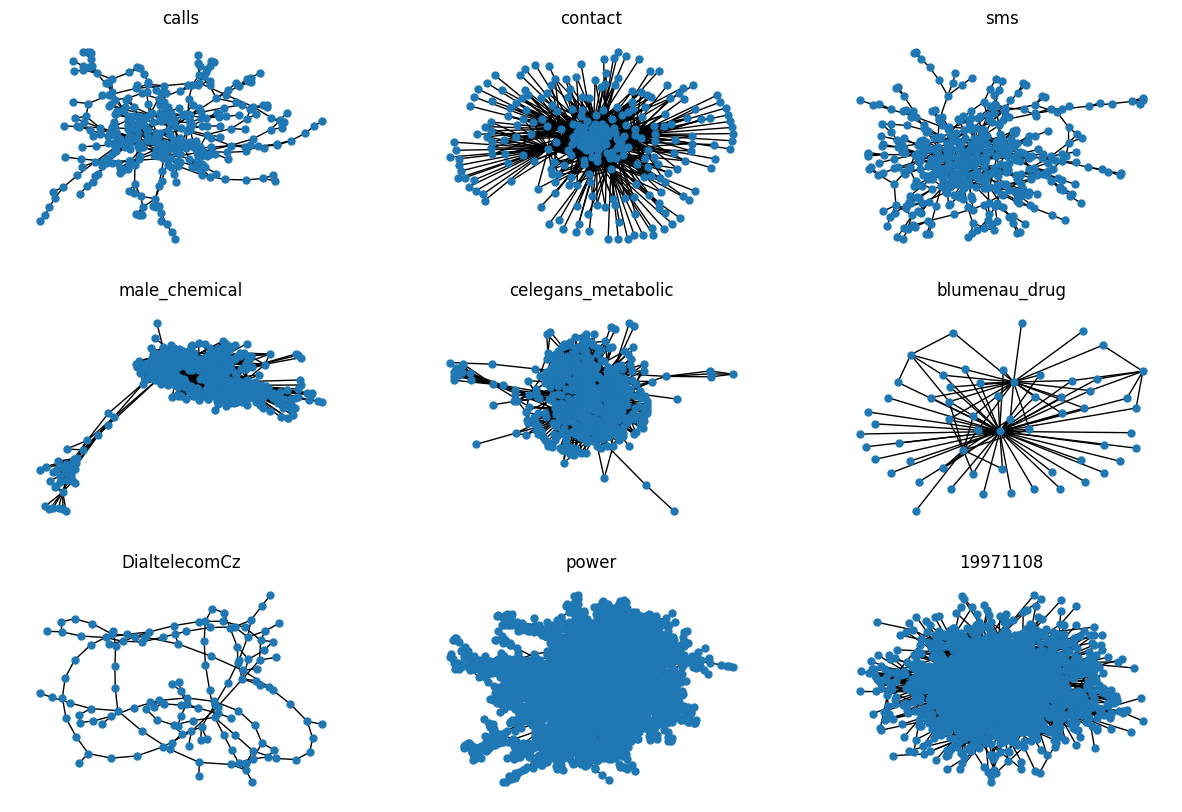

In [23]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for ax, file in zip(axes.ravel(), files):
    df = pd.read_csv(
        DATA_DIR / "chosen" / file / "edges.csv",
        delimiter=",",
        comment="#",
        names=["source", "target", "timestamp", "duration"],
    )

    G = nx.from_pandas_edgelist(
        df, source="source", target="target", create_using=nx.Graph()
    )

    G = normalize_graph(G)

    pos = nx.spring_layout(G)
    nx.draw(G, pos=pos, ax=ax, node_size=25)
    ax.set_title(file)

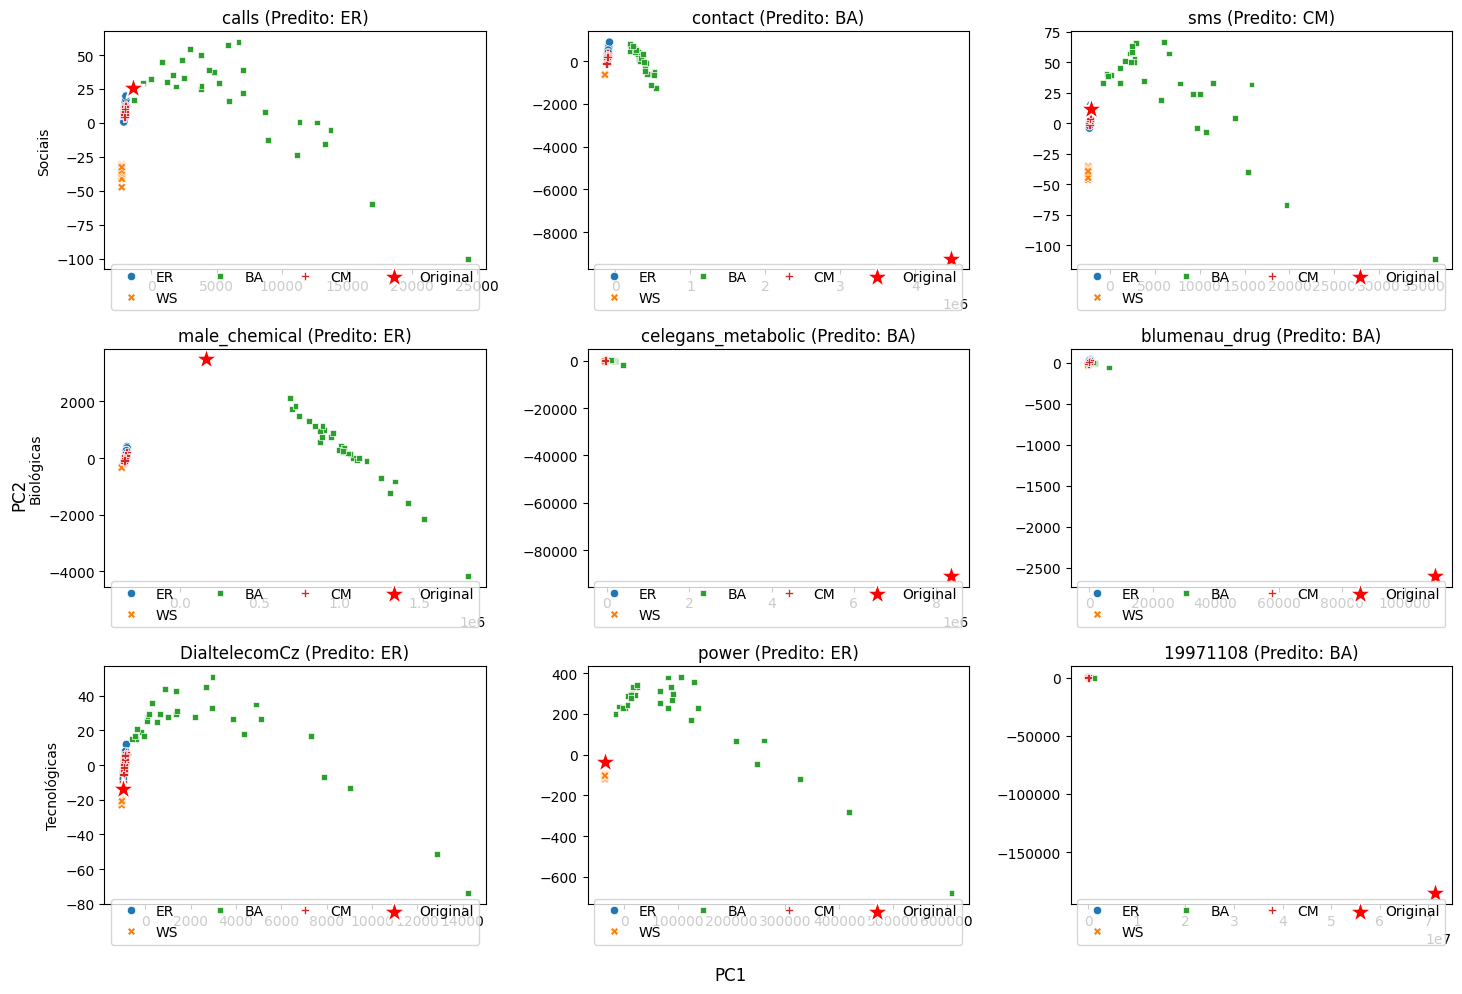

In [25]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.supxlabel("PC1")
fig.supylabel("PC2")

for ax, file in zip(axes.ravel(), files):
    df = pd.read_csv(
        DATA_DIR / "chosen" / file / "edges.csv",
        delimiter=",",
        comment="#",
        names=["source", "target", "timestamp", "duration"],
    )

    G = nx.from_pandas_edgelist(
        df, source="source", target="target", create_using=nx.Graph()
    )

    G = normalize_graph(G)
    ms = pd.DataFrame([measures(G)])
    nets = simulate_nets(G, models, N_NETS)
    clf = make_classifier(nets, "model")
    predicted = clf.predict(ms)
    ax = plot_results(
        nets=nets,
        measures=ms,
        n_components=2,
        ax=ax,
    )
    ax.set_title(f"{file} (Predito: {predicted[0]})")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.20), ncol=4)

for row, ax in zip(["Sociais", "Biológicas", "Tecnológicas"], axes):
    ax[0].set_ylabel(row)

_ = fig.tight_layout()